#**Objetivos**
* Construir Pipelines de procesamiento de datos.
* Probar modelos de Regresión logística, SVM y modelos de árboles.

#**Pasos**
* Cargar la data.
* Separar la data en conjunto de train y test.
* Aplicar técnicas de balanceo de datos.
* Utilizar Pipeline y ImbPipeline.
* Probar ajuste de hiperparámetros y trackear con MlFlow


#**Librerías**

##**Instalar librería para procesamiento de datos**

In [1]:
!pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 5.7 MB/s eta 0:00:00


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from feature_engine.encoding import OneHotEncoder, OrdinalEncoder
from feature_engine.wrappers import SklearnTransformerWrapper
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from sklearn.base import BaseEstimator, clone, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import classification_report, precision_recall_curve, PrecisionRecallDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

#**Cargar la data**

In [6]:
df = pd.read_csv('Telco-Customer-Churn.csv')

In [7]:
df['customerID'].dtype

dtype('O')

#**Transformar la variable objetivo a 0 y 1**

In [8]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

#**Pipeline de Procesamiento de Datos**

##**Transformador personalizado para seleccionar variables**
* Construiré un transformar personalizado que permita seleccionar las variables, ya que se probarán distintas combinaciones de variables y no tener que estar usando drop cada vez.

In [9]:
class ColumnSelector(BaseEstimator, TransformerMixin):
  def __init__(self, columns_to_select):
    self.columns_to_select = columns_to_select

  def fit(self, X, y=None):
    return self

  def transform(self,X):
    return X[self.columns_to_select]

##**Separar la data en Train y Test**

In [12]:
X = df.drop(columns = 'Churn')
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

##**Lista de columnas que se usarán en el pipeline**
* La idea de tener una lista de variables a seleccionar es para evitar tener que estar modificando X a cada momento, ya que se utilizarán distintas combinaciones.
* También se debe tener una lista de variables para las cuales se aplicarán los transformadores como StandardScaler que solo se aplica a variables numéricas, mientras que el OneHotEncoder y LabelEncoder solo lo aplicaremos a las variables de tipo String u Object.

In [17]:
lista_seleccionadas = list(X.drop(columns=['TotalCharges','customerID']).columns)
lista_continuas = list(X.select_dtypes('number').drop(columns=['SeniorCitizen']).columns)
lista_strings = list(X.select_dtypes('object').drop(columns=['TotalCharges', 'customerID']).columns)

##**Función personalizada que permita comparar los gráficos de Precisión Sensibilidad de 2 modelos**
* Haré una función para evitar tener que escribir el mismo código una y otra vez.

In [10]:
def graficar_curvas_precision_recall(lista_modelos:list[tuple[BaseEstimator, str]]):
  fig, ax = plt.subplots(1, 2, figsize = (15, 7))

  for j, (model, name) in enumerate(lista_modelos):
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax[j], name=name)
    ax[j].set_xlabel('Recall (Sensibilidad)', fontsize = 14, fontweight = 'bold')
    ax[j].set_ylabel('Precision', fontsize = 14, fontweight = 'bold')
    ax[j].set_title(f'Curva Precisión-Sensibilidad{name}', fontsize = 16, fontweight = 'bold')
  plt.tight_layout()
  plt.show()

##**Pipeline Para Modelos lineales**

##**Pipeline para regresión logística**

In [18]:
pipeline_lr = Pipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('scaler', SklearnTransformerWrapper(StandardScaler(), variables=lista_continuas)),
    ('encoding', OneHotEncoder(variables=lista_strings,drop_last=True, top_categories = None)),
    ('model', LogisticRegressionCV())])

##**Pipeline para modelos no lineales**
* En este caso no es necesario utilizar un escalamiento de las variables ya que los modelos de árboles no son sensibles a la magnitud de las variables continuas, además probaré utilizando LabelEncoder y OneHotEncoder para ver cual da mejores resultados

In [19]:
preprocesor_no_lineal_ohe = ColumnTransformer(transformers = [
    ('encoding', OneHotEncoder(top_categories = None), lista_strings)
])

preprocesor_no_lineal_oe = ColumnTransformer(transformers = [
    'encoding', OrdinalEncoder(encoding_method='ordered'), lista_strings
])

pipeline_no_lineal_ohe = Pipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('preprocesor', preprocesor_no_lineal_ohe)
])


pipeline_no_lineal_oe = Pipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('preprocesor', preprocesor_no_lineal_oe)
])

#**Regresión logística sin balanceo**
* Aquí probaré un primero modelo de regresión logística para tener un primer acercamiento al problema, en el cual no realizaré balanceo, ni ajustaré el threshold para luego ir probando

In [20]:
lr_reference_model = pipeline_lr.fit(X_train, y_train)
y_pred = pipeline_lr.predict(X_test)

##**Métricas para evaluar el modelo**

##**Classification Report**

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.76      1409
weighted avg       0.81      0.82      0.82      1409



##**Curva de precisión sensibilidad**

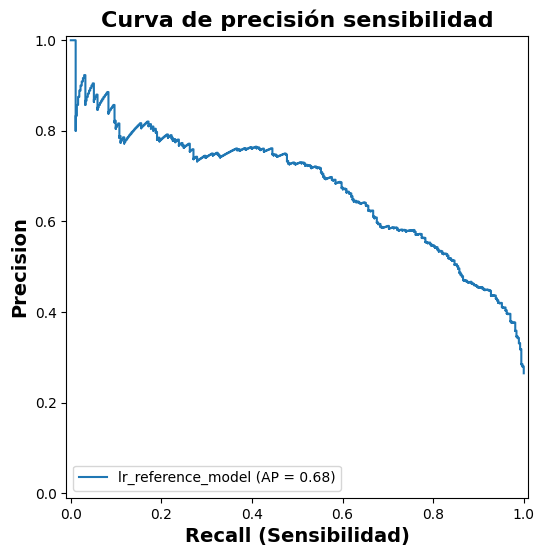

In [22]:
fig, ax = plt.subplots(figsize = (10,6))


PrecisionRecallDisplay.from_estimator(lr_reference_model, X_test, y_test, ax = ax, name='lr_reference_model')
ax.set_xlabel('Recall (Sensibilidad)', fontsize = 14, fontweight = 'bold')
ax.set_ylabel('Precision', fontsize = 14, fontweight = 'bold')
ax.set_title('Curva de precisión sensibilidad', fontsize = 16, fontweight = 'bold')
plt.show()

#**Evaluar el overfitting del modelo**
* Para esto compararemos los resultados que nos dio al predecir el conjunto de test con respecto a los resultados que obtendremos del conjunto de train

In [23]:
y_pred_train = lr_reference_model.predict(X_train)

resultados_train_lr = classification_report(y_train, y_pred_train)
resultados_test_lr = classification_report(y_test, y_pred)

print(f'Resultados conjunto de entrenamiento:  \n\n {resultados_train_lr} \n\n resultados conjunto de test: \n\n {resultados_test_lr}')

Resultados conjunto de entrenamiento:  

               precision    recall  f1-score   support

           0       0.84      0.90      0.87      4138
           1       0.65      0.53      0.59      1496

    accuracy                           0.80      5634
   macro avg       0.75      0.72      0.73      5634
weighted avg       0.79      0.80      0.79      5634
 

 resultados conjunto de test: 

               precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.76      1409
weighted avg       0.81      0.82      0.82      1409



#**Segundo Modelo Regresión logística con Class_weight**
* Probaré un segundo modelo utilizando el parámetro weighted de regresión logística para que le dé más peso a la clase que aparece menos, para esto debo copiar el Pipeline hecho anteriormente y modificar un parámetro del modelo, se hizo una copia de este en vez de modificar el primer Pipeline para luego poder comparar con otros métodos de balanceo de clases como Smote o NearMiss

In [24]:
lr_balanceado = clone(pipeline_lr)
lr_balanceado.set_params(model = LogisticRegressionCV(class_weight='balanced'))
lr_balanceado.fit(X_train, y_train)
y_pred_lr_balanceado = lr_balanceado.predict(X_test)
y_pred_proba_lr_balanceado = lr_balanceado.predict_proba(X_test)

#**Métricas para evaluar el modelo**

In [25]:
print(classification_report(y_test, y_pred_lr_balanceado))

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1036
           1       0.53      0.82      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.76      0.77      1409



#**Comparación de gráficos de Precisión Sensibilidad**

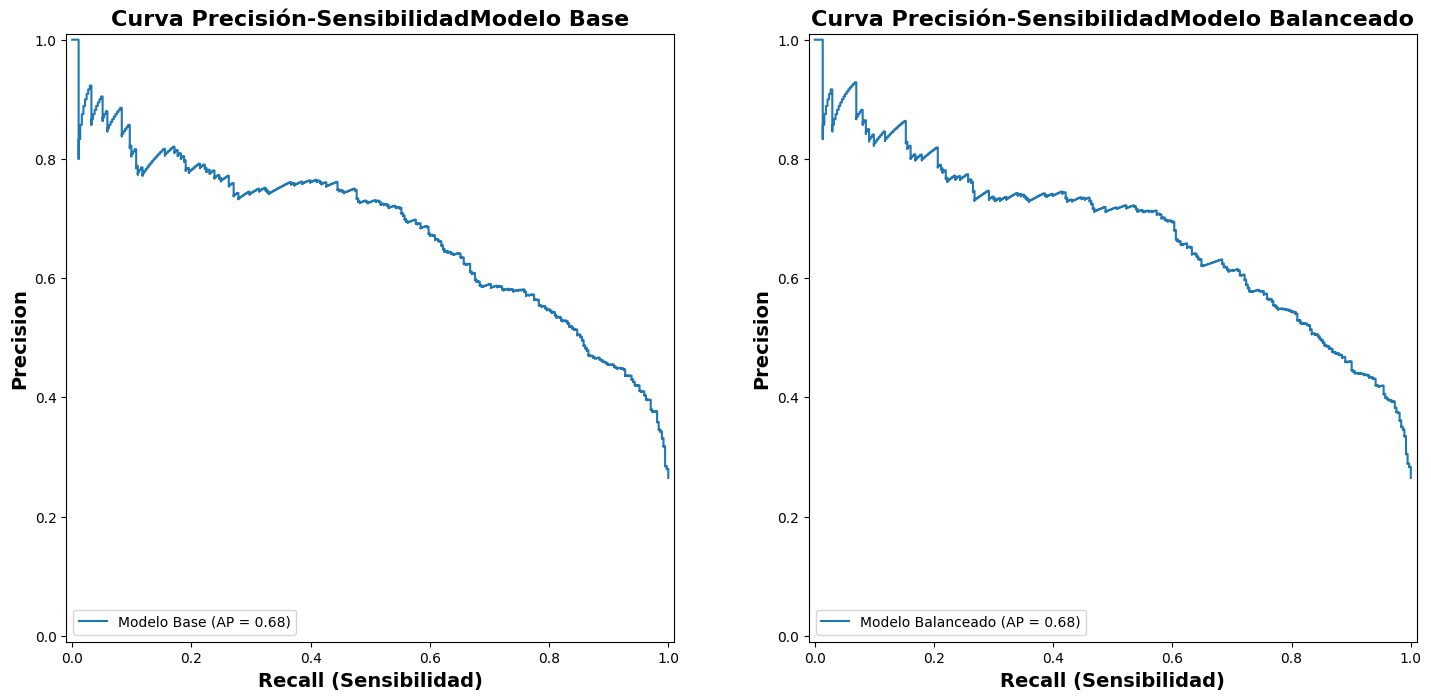

In [26]:
lista_modelos_lr_balanceado = [(lr_reference_model,'Modelo Base'), (lr_balanceado,'Modelo Balanceado')]

graficar_curvas_precision_recall(lista_modelos_lr_balanceado)


#**Modelo utilizando Smote para balancear**
* Aquí crearé un nuevo Pipeline basándome en el original, pero antes de seleccionar el modelo, se agrega una técnica de balanceo llamada SMOTE

In [27]:
lr_smote = ImbPipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('scaler', SklearnTransformerWrapper(StandardScaler(), variables=lista_continuas)),
    ('encoding', OneHotEncoder(variables=lista_strings,drop_last=True, top_categories = None)),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegressionCV())])

lr_smote.fit(X_train, y_train)
y_pred_lr_smote = lr_smote.predict(X_test)
y_pred_proba_lr_smote = lr_smote.predict_proba(X_test)

#**Métricas del modelo Logistic Regression con SMOTE**

In [28]:
print(classification_report(y_test, y_pred_lr_smote))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1036
           1       0.54      0.72      0.62       373

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



##**Comparar gráfico de precisión Sensibilidad para Modelo con balanceo SMOTE**

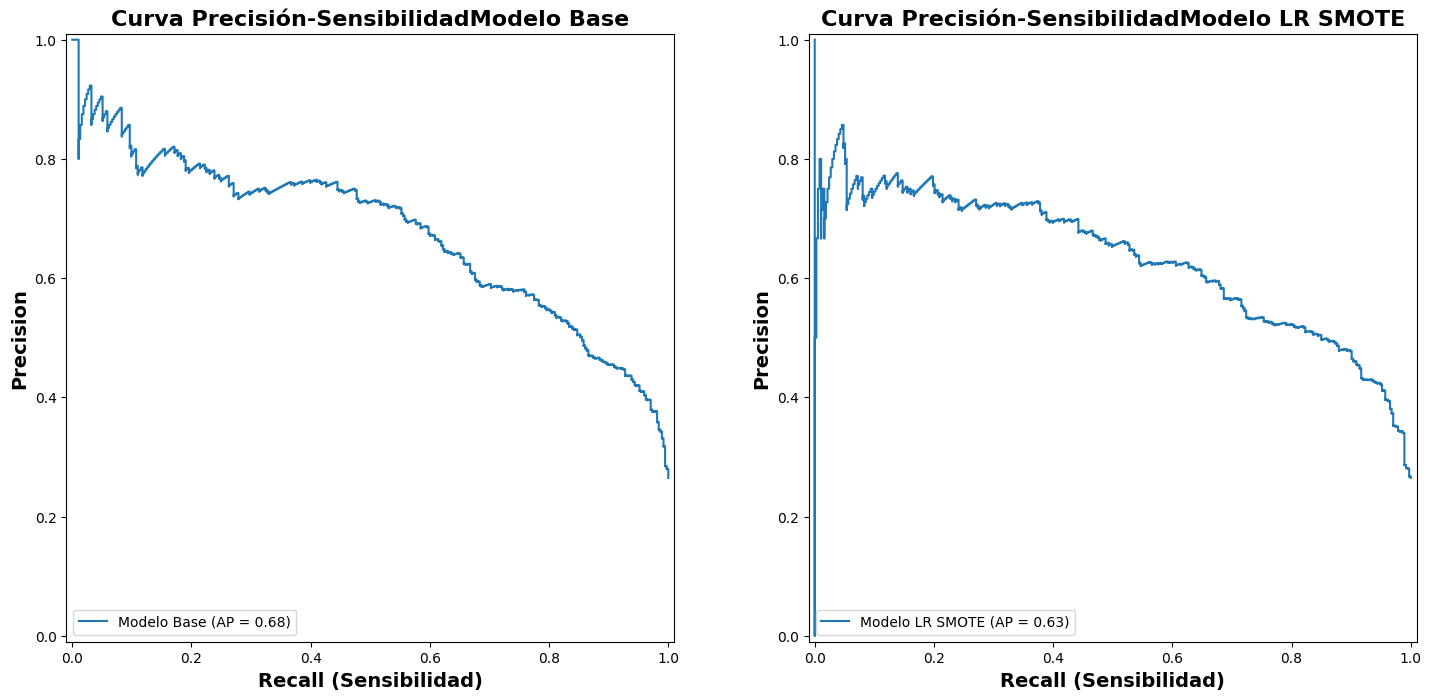

In [29]:
lista_modelos_lr_smote = [(lr_reference_model, 'Modelo Base'), (lr_smote, 'Modelo LR SMOTE')]

graficar_curvas_precision_recall(lista_modelos_lr_smote)

#**Modelo utilizando NearMiss para balancear**
* Ahora se utilizará otra técnica para balancear los datos, también se debe realizar otro Pipeline para procesar estos datos e incluir el balanceador.

In [30]:
lr_near_miss = ImbPipeline([
    ('Selector', ColumnSelector(lista_seleccionadas)),
    ('scaler', SklearnTransformerWrapper(StandardScaler(), variables=lista_continuas)),
    ('encoding', OneHotEncoder(variables=lista_strings,drop_last=True, top_categories = None)),
    ('near_miss', NearMiss(version=3)),
    ('model', LogisticRegressionCV())])

lr_near_miss.fit(X_train, y_train)
y_pred_lr_near_miss = lr_near_miss.predict(X_test)
y_pred_proba_lr_near_miss = lr_near_miss.predict_proba(X_test)

#**Métricas para NearMiss**

In [31]:
print(classification_report(y_test, y_pred_lr_near_miss))

              precision    recall  f1-score   support

           0       0.89      0.82      0.85      1036
           1       0.59      0.72      0.65       373

    accuracy                           0.79      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.79      0.80      1409



##**Comparación de gráfico Precisión Sensibilidad para Modelo NearMiss**

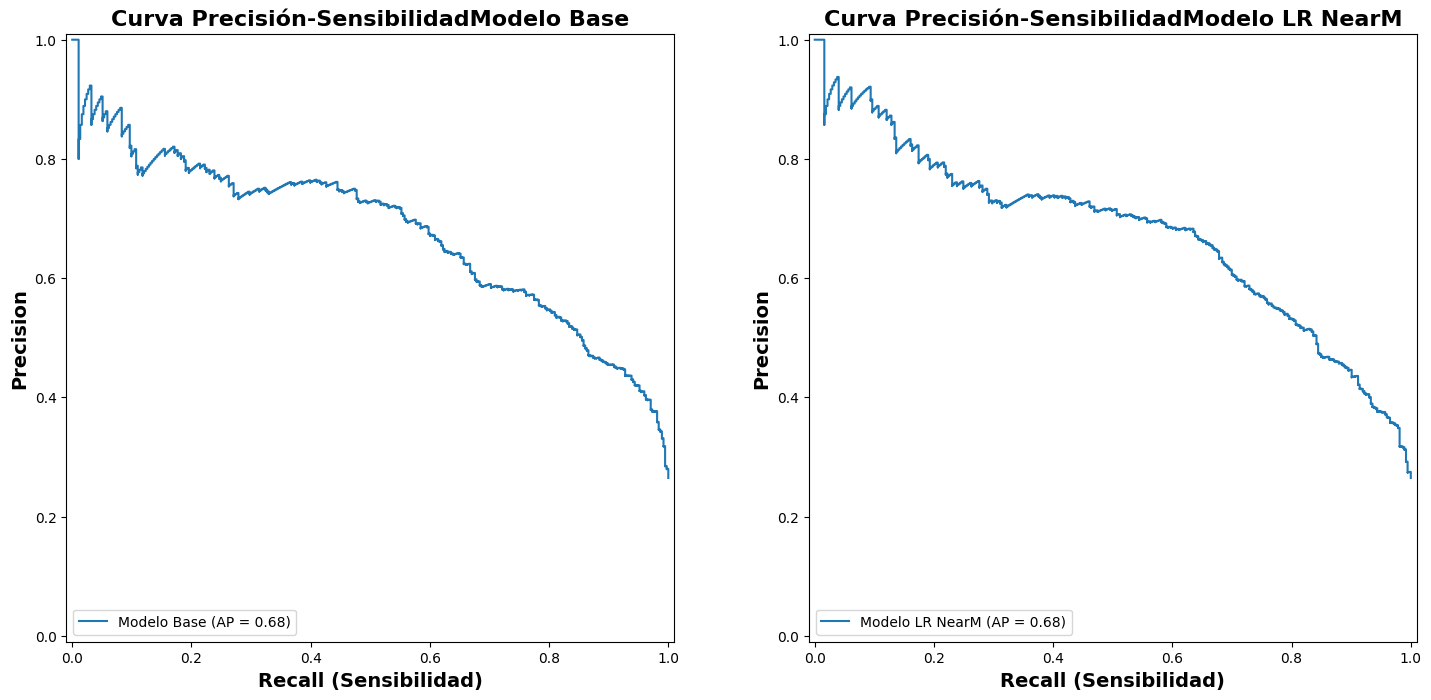

In [32]:
lista_modelos_lr_near_miss = [
    (lr_reference_model,'Modelo Base'), (lr_near_miss,'Modelo LR NearM')]

graficar_curvas_precision_recall(lista_modelos_lr_near_miss)